In [5]:
import tensorflow as tf
from tensorflow import keras
import glob
import numpy as np
import sys
import os

sys.path.insert(1, '../scripts')
sys.path.insert(1, '../stella')
import stella
from utils import *
import lightkurve as lk
import os
import matplotlib.pyplot as plt
from tqdm import tqdm
import pickle

In [6]:
with open("../datasets-opt/comets-plus-aug-planets-binaries-sines-1.5.pkl", "rb") as file:
    data = pickle.load(file)
    ds = data['dataset']

In [7]:
cnn = stella.ConvNN(output_dir='../cnn-models/',ds=ds)

In [36]:
def find_models(path):
    """
    Returns the CNN model(s) as a list of paths.
    If path is a directory, it globs for .h5 files.
    If path is a file, it returns a list with that single file.
    """
    model_paths = []
    for p in path:
        if os.path.isdir(p):
            model_paths.extend(glob.glob(f"{p}/*.h5"))
        elif os.path.isfile(p) and p.endswith(".h5"):
            model_paths.append(p)
    return model_paths


def scale_lightcurve(time, flux, flux_error):
    f = np.array((flux / np.nanmedian(flux)) - 1)
    mask = ~np.isnan(flux)
    t = time[mask]
    f = f[mask]
    flux_error = flux_error[mask]

    f = (f - np.min(f)) / (np.max(f) - np.min(f))
    del mask
    return t, f, flux_error

def process_lightcurve(lc):

    
        time = lc.time.value
        flux = lc.flux.value
        flux_error = lc.flux_err.value
    
        # Handle NaN values more efficiently
        mask = ~np.isnan(time) & ~np.isnan(flux) & ~np.isnan(flux_error)
        time = time[mask]
        flux = flux[mask]
        flux_error = flux_error[mask]
        
        # Keep original data only for interesting events
        original_time = time.copy()
        original_flux = flux / np.nanmedian(flux)
        
        # Scale the flux
        flux = flux / np.nanmedian(flux) - 1
        flux = (flux - np.min(flux)) / (np.max(flux) - np.min(flux))
        
        return time, flux, flux_error, original_flux, original_time


In [328]:
models = ['../cnn-models/ensemble_s0610_i0100_b0.58.h5',
         '../cnn-models/ensemble_s0611_i0100_b0.58.h5',
         '../cnn-models/ensemble_s0612_i0100_b0.58.h5',
         '../cnn-models/ensemble_s0613_i0100_b0.58.h5',
         '../cnn-models/ensemble_s0614_i0100_b0.58.h5']

---

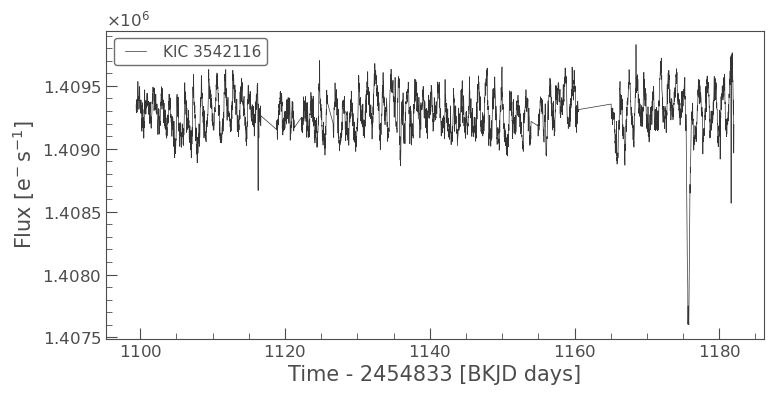

In [319]:
lk.search_lightcurve('KIC 3542116')[12].download().plot();

In [330]:
ids = 'Beta Pic'
lc = lk.search_lightcurve(ids,sector=6,author='TESS-SPOC').download()
lc = lc[lc.quality.value == 0]

In [331]:
lc = process_lightcurve(lc)
time = lc[0]
flux = lc[1]
flux_error = lc[2]

cnn.predict(modelname=models[1],
            times=time,
            fluxes=flux,
            errs=flux_error)
single_pred = cnn.predictions[0]

preds = np.zeros((len(models), len(lc[1])))

for i, model in enumerate(models):
    try:        
        cnn.predict(modelname=model, times=time, fluxes=flux, errs=flux_error)
        preds[i] = cnn.predictions[0]

    except Exception as e:
        preds[i] = np.nan

avg_pred = np.nanmedian(preds, axis=0)

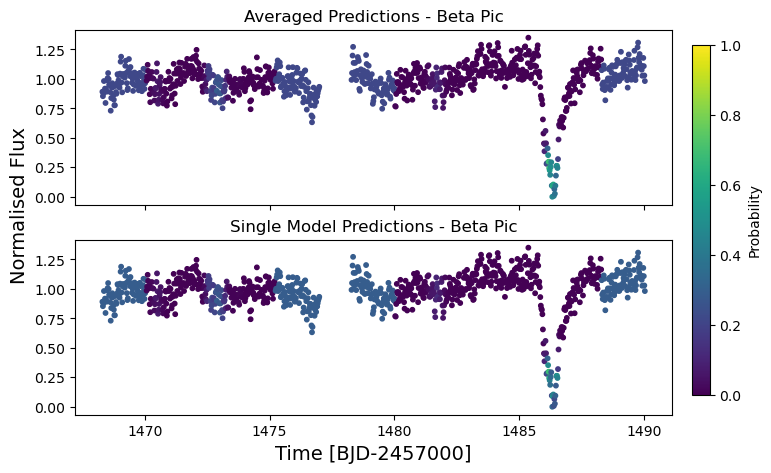

In [332]:
fig, (ax1, ax2) = plt.subplots(figsize=(9,5), nrows=2,
                               sharex=True, sharey=True)
im = ax1.scatter(cnn.predict_time[0], cnn.predict_flux[0],
            c=avg_pred, vmin=0, vmax=1,s=10)
ax2.scatter(cnn.predict_time[0], cnn.predict_flux[0],
            c=single_pred, vmin=0, vmax=1,s=10)
ax2.set_xlabel('Time [BJD-2457000]',fontsize=14)
ax2.set_ylabel('Normalised Flux', y=1.2,fontsize=14)

fig.subplots_adjust(right=0.788)
cbar_ax = fig.add_axes([0.81, 0.15, 0.02, 0.7])
fig.colorbar(im, cax=cbar_ax, label='Probability')


ax1.set_title(f'Averaged Predictions - {ids}')
ax2.set_title(f'Single Model Predictions - {ids}')

plt.subplots_adjust(hspace=0.2)
plt.savefig(f'paper-plots/{ids}-q12-pred-comets-only.pdf',dpi=300,bbox_inches='tight');